Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


Load Dataset ONCE

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df.to_csv("titanic.csv", index=False)

Dataset Profiling

In [4]:
print(df.shape)

print(df.info())

print(df.describe())

(891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
         survived      pclass         age       sibsp       parch        fare
c

Missing Percentage

In [5]:
missing_percent = (
    df.isnull().sum()
    / len(df)
) * 100

print(
    missing_percent[
        missing_percent > 0
    ]
)

age            19.865320
embarked        0.224467
deck           77.216611
embark_town     0.224467
dtype: float64


Missing Value Treatment Below 5%

In [6]:
df = df.dropna(
subset=['embarked', 'embark_town']
)

5%-30%

In [7]:
df['age'] = df['age'].fillna(
    df['age'].median()
)

Above 30%

In [8]:
df.drop(
    columns=['deck'],
    inplace=True
)

Age Histogram

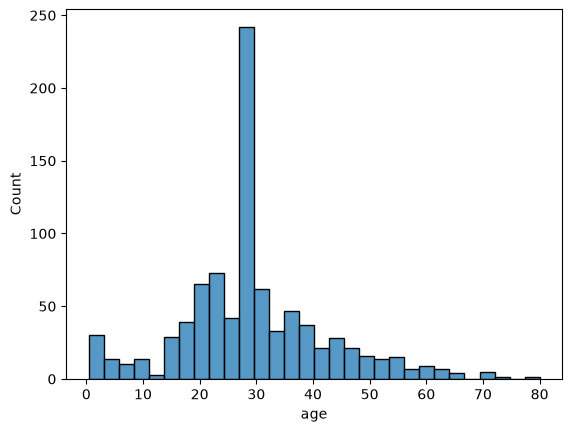

In [9]:
sns.histplot(df['age'])

plt.show()

Age Boxplot

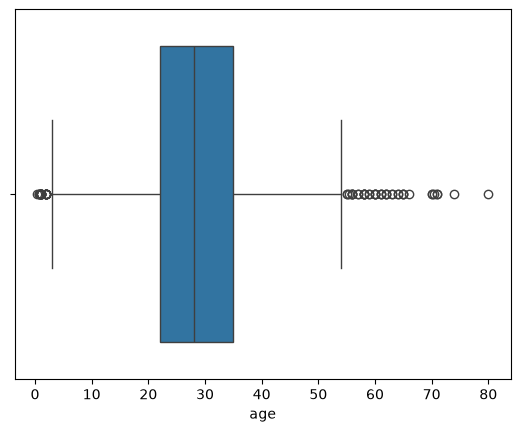

In [10]:
sns.boxplot(x=df['age'])

plt.show()

Fare Histogram

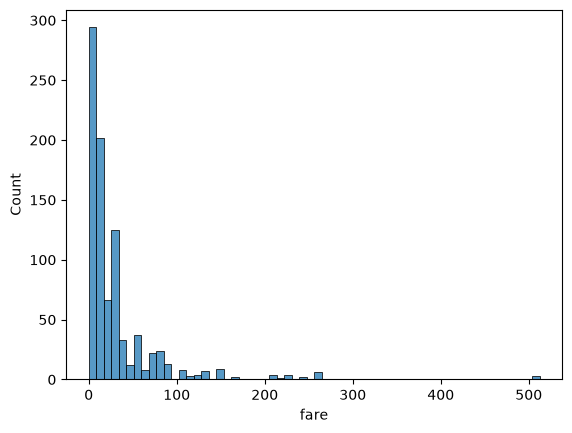

In [12]:
sns.histplot(df['fare'])

plt.show()

Fare Boxplot

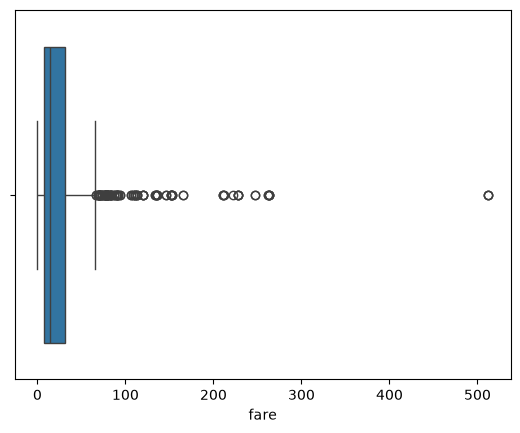

In [13]:
sns.boxplot(
    x=df['fare']
)

plt.show()

IQR Outliers

In [14]:
def count_outliers(series):

    q1 = series.quantile(0.25)

    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr

    upper = q3 + 1.5 * iqr

    outliers = ((series < lower) |
                (series > upper)).sum()

    return outliers

In [15]:
print(
    count_outliers(df['age'])
)

65


In [16]:
print(
    count_outliers(df['fare'])
)

114


Mean Median Mode

In [17]:
print(
    df['fare'].mean()
)

print(
    df['fare'].median()
)

print(
    df['fare'].mode()[0]
)

32.09668087739032
14.4542
8.05


Mean > Median > Mode

Therefore right-skewed.

Survival By Sex

In [19]:
male_rate = df[
    df['sex']=="male"
]['survived'].mean()

female_rate = df[
    df['sex']=="female"
]['survived'].mean()

print(male_rate)
print(female_rate)

0.18890814558058924
0.7403846153846154


Survival By Class

In [21]:
for p in [1,2,3]:

    rate = df[
        df['pclass']==p
    ]['survived'].mean()

    print(rate)

0.6261682242990654
0.47282608695652173
0.24236252545824846


Sex + Class Together

In [22]:
for sex in ['male','female']:

    for p in [1,2,3]:

        rate = df[
            (df['sex']==sex)
            &
            (df['pclass']==p)
        ]['survived'].mean()

        print(
            sex,
            p,
            rate
        )

male 1 0.36885245901639346
male 2 0.1574074074074074
male 3 0.13544668587896252
female 1 0.967391304347826
female 2 0.9210526315789473
female 3 0.5


Correlation Matrix

In [24]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [26]:
corr_cols = [
    'survived',
    'pclass',
    'age',
    'sibsp']

corr = df[corr_cols].corr()

Heatmap

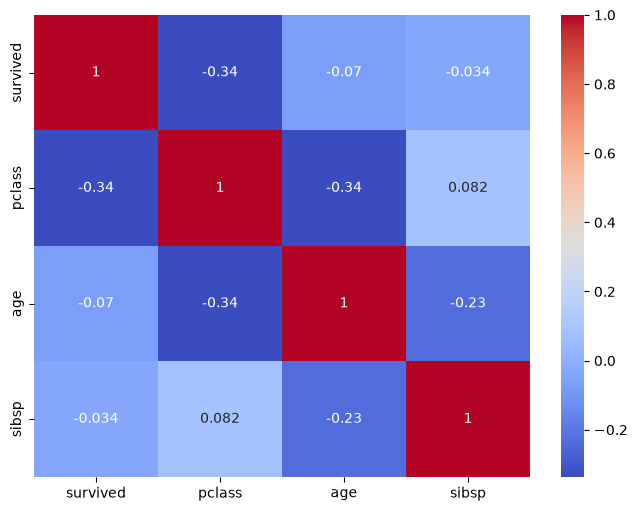

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

Four Multivariate Charts

<Axes: xlabel='sex', ylabel='survived'>

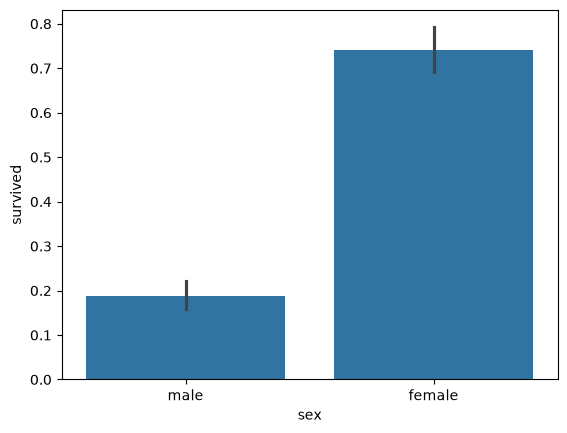

In [28]:
sns.barplot(
    x='sex',
    y='survived',
    data=df
)

chart2

<Axes: xlabel='pclass', ylabel='survived'>

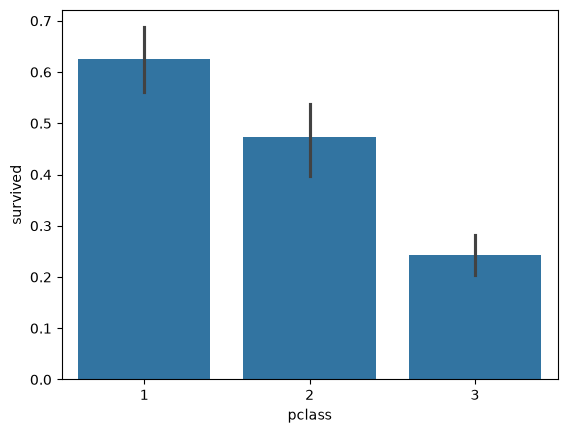

In [29]:
sns.barplot(
    x='pclass',
    y='survived',
    data=df
)

chart3

<Axes: xlabel='survived', ylabel='fare'>

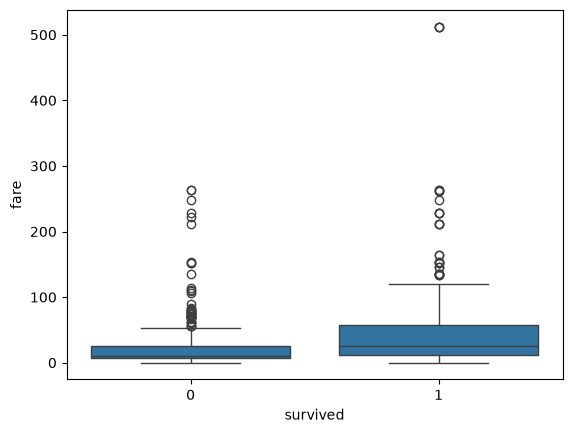

In [30]:
sns.boxplot(
    x='survived',
    y='fare',
    data=df
)

chart4

<Axes: xlabel='age', ylabel='fare'>

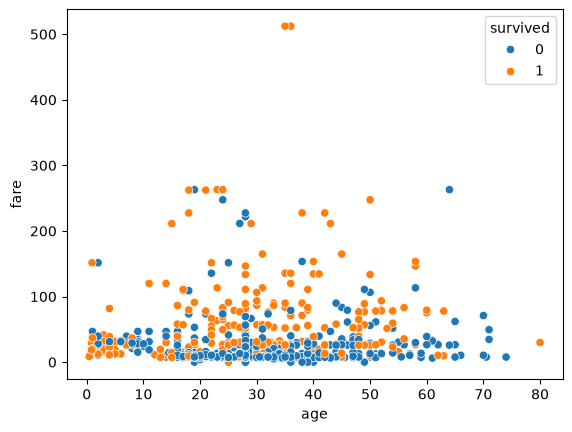

In [31]:
sns.scatterplot(
    x='age',
    y='fare',
    hue='survived',
    data=df
)

Standardization

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['age_z','fare_z']] = scaler.fit_transform(
    df[['age','fare']]
)

print(
    df[['age_z','fare_z']]
    .agg(['mean','std'])
)

             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00
